# VGAE Baseline - 3-Fold CV + Kaggle Submission

Variational Graph Auto-Encoder (VGAE) baseline for the brain graph super-resolution task.
Simple architecture: 2-layer GCN encoder, deterministic latent, inner-product decoder.
Evaluate on all 8 metrics and produce a submission CSV for Kaggle.

In [9]:
import sys
from pathlib import Path

notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / 'gcn-encoder-ca-decoder'))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import time

from data_utils import vec_to_adj, lr_node_features, to_tensor
from models.vgae import VGAEBaseline
from utils.matrix_vectorizer import MatrixVectorizer
from utils.metrics import evaluate_fold
from utils.plotting import plot_folds

DEVICE = 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cpu


## Load Data

In [3]:
def load_csv(path):
    arr = np.loadtxt(path, delimiter=',', skiprows=1, dtype=np.float32)
    return arr if arr.ndim > 1 else arr[None, :]

X_lr_train = load_csv(repo_root / 'data' / 'lr_train.csv')
Y_hr_train = load_csv(repo_root / 'data' / 'hr_train.csv')
X_lr_test  = load_csv(repo_root / 'data' / 'lr_test.csv')

print(f'Train LR: {X_lr_train.shape}')
print(f'Train HR: {Y_hr_train.shape}')
print(f'Test  LR: {X_lr_test.shape}')

Train LR: (167, 12720)
Train HR: (167, 35778)
Test  LR: (112, 12720)


## Config

In [4]:
N_LR, N_HR = 160, 268

# VGAE model hyperparameters
HIDDEN_DIM = 64
LATENT_DIM = 64
IN_NODE_FEAT_DIM = 2

# Training hyperparameters
EPOCHS = 50
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-5

print(f'VGAE config:')
print(f'  Hidden dim: {HIDDEN_DIM}')
print(f'  Latent dim: {LATENT_DIM}')
print(f'  Input node features: {IN_NODE_FEAT_DIM}')
print(f'Training: {EPOCHS} epochs, bs={BATCH_SIZE}, lr={LR}')

VGAE config:
  Hidden dim: 64
  Latent dim: 64
  Input node features: 2
Training: 50 epochs, bs=16, lr=0.001


## VGAE Model Definition

In [6]:
print("VGAE model loaded from models/vgae.py")
print(f"  - VGAEBaseline: 2-layer GCN encoder + inner-product decoder")
print(f"  - Architecture: {N_LR} → {HIDDEN_DIM} → {LATENT_DIM} → {N_HR}")

VGAE model loaded from models/vgae.py
  - VGAEBaseline: 2-layer GCN encoder + inner-product decoder
  - Architecture: 160 → 64 → 64 → 268


## Training Loop (Single Fold)

In [7]:
def train_one_fold(X_tr, Y_tr, X_va, Y_va, fold_id):
    """Train VGAE on one fold with early stopping."""
    Xtr, Ytr = to_tensor(X_tr, DEVICE), to_tensor(Y_tr, DEVICE)
    Xva, Yva = to_tensor(X_va, DEVICE), to_tensor(Y_va, DEVICE)
    
    tr_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Yva), batch_size=BATCH_SIZE, shuffle=False)
    
    model = VGAEBaseline(
        n_lr=N_LR, n_hr=N_HR,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        in_node_feat_dim=IN_NODE_FEAT_DIM,
        dropout=0.1
    ).to(DEVICE)
    
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    
    best_val_loss = float('inf')
    best_state = None
    patience = 15
    patience_counter = 0
    
    fold_start_time = time.time()
    
    for epoch in range(1, EPOCHS + 1):
        # Training phase
        model.train()
        for x_vec, y_vec in tr_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = lr_node_features(A)
            
            pred = model(A, X)
            loss = loss_fn(pred, y_vec)
            
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        
        # Validation phase
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_vec, y_vec in va_loader:
                A = vec_to_adj(x_vec, N_LR)
                X = lr_node_features(A)
                pred = model(A, X)
                val_losses.append(loss_fn(pred, y_vec).item())
        
        val_loss = np.mean(val_losses)
        improved = val_loss < best_val_loss
        
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if epoch % 10 == 0 or epoch == 1:
            mark = ' *' if improved else ''
            print(f'  Fold {fold_id} | Epoch {epoch:3d}/{EPOCHS} | Val MSE: {val_loss:.6f}{mark}')
        
        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break
    
    fold_time = time.time() - fold_start_time
    model.load_state_dict(best_state)
    print(f'  Fold {fold_id} best val MSE: {best_val_loss:.6f} | Time: {fold_time:.2f}s')
    
    return model

## 3-Fold Cross-Validation + Metrics

In [10]:
kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
vectorizer = MatrixVectorizer()

fold_metrics = []
fold_models = []
fold_times = []

overall_start = time.time()

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_lr_train), start=1):
    print(f"\n{'='*50}")
    print(f'Fold {fold_id}: train={len(tr_idx)}, val={len(va_idx)}')
    print(f"{'='*50}")
    
    model = train_one_fold(
        X_lr_train[tr_idx], Y_hr_train[tr_idx],
        X_lr_train[va_idx], Y_hr_train[va_idx],
        fold_id,
    )
    fold_models.append(model)
    
    # Evaluate on validation set
    model.eval()
    va_preds, va_targets = [], []
    va_loader = DataLoader(
        TensorDataset(
            to_tensor(X_lr_train[va_idx], DEVICE),
            to_tensor(Y_hr_train[va_idx], DEVICE)
        ),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    
    with torch.no_grad():
        for x_vec, y_vec in va_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = lr_node_features(A)
            va_preds.append(model(A, X).cpu().numpy())
            va_targets.append(y_vec.cpu().numpy())
    
    pred_vecs = np.concatenate(va_preds)
    gt_vecs = np.concatenate(va_targets)
    pred_mats = np.stack([vectorizer.anti_vectorize(v, N_HR) for v in pred_vecs])
    gt_mats = np.stack([vectorizer.anti_vectorize(v, N_HR) for v in gt_vecs])
    
    print(f'\n  Metrics for fold {fold_id}:')
    metrics = evaluate_fold(pred_mats, gt_mats, verbose=True)
    fold_metrics.append(metrics)

overall_time = time.time() - overall_start
print(f'\n\nAll 3 folds evaluated in {overall_time:.2f}s')


Fold 1: train=111, val=56
  Fold 1 | Epoch   1/50 | Val MSE: 1653.134048 *
  Fold 1 | Epoch  10/50 | Val MSE: 30.963441 *
  Fold 1 | Epoch  20/50 | Val MSE: 9.056237 *
  Fold 1 | Epoch  30/50 | Val MSE: 4.575173 *
  Fold 1 | Epoch  40/50 | Val MSE: 2.837015 *
  Fold 1 | Epoch  50/50 | Val MSE: 1.995038 *
  Fold 1 best val MSE: 1.995038 | Time: 72.44s

  Metrics for fold 1:


Graph metrics: 100%|██████████| 56/56 [16:53<00:00, 18.10s/it]


Evaluation metrics:
  MAE             : 0.672965
  PCC             : 0.035105
  JSD             : 0.613599
  MAE (PC)        : 0.001097
  MAE (EC)        : 0.022579
  MAE (BC)        : 0.022114
  MAE (Strength)  : 98.670574
  MAE (Clustering): 0.231738

Fold 2: train=111, val=56
  Fold 2 | Epoch   1/50 | Val MSE: 2070.111526 *
  Fold 2 | Epoch  10/50 | Val MSE: 59.382513 *
  Fold 2 | Epoch  20/50 | Val MSE: 17.119530 *
  Fold 2 | Epoch  30/50 | Val MSE: 8.996966 *
  Fold 2 | Epoch  40/50 | Val MSE: 5.856796 *
  Fold 2 | Epoch  50/50 | Val MSE: 4.288979 *
  Fold 2 best val MSE: 4.288979 | Time: 70.00s

  Metrics for fold 2:


Graph metrics: 100%|██████████| 56/56 [16:34<00:00, 17.75s/it]


Evaluation metrics:
  MAE             : 0.826587
  PCC             : 0.060101
  JSD             : 0.619408
  MAE (PC)        : 0.001118
  MAE (EC)        : 0.023538
  MAE (BC)        : 0.022388
  MAE (Strength)  : 138.482898
  MAE (Clustering): 0.239933

Fold 3: train=112, val=55
  Fold 3 | Epoch   1/50 | Val MSE: 991.002579 *
  Fold 3 | Epoch  10/50 | Val MSE: 21.699500 *
  Fold 3 | Epoch  20/50 | Val MSE: 5.850077 *
  Fold 3 | Epoch  30/50 | Val MSE: 2.705014 *
  Fold 3 | Epoch  40/50 | Val MSE: 1.546500 *
  Fold 3 | Epoch  50/50 | Val MSE: 1.014588 *
  Fold 3 best val MSE: 1.014588 | Time: 71.84s

  Metrics for fold 3:


Graph metrics: 100%|██████████| 55/55 [16:30<00:00, 18.01s/it]

Evaluation metrics:
  MAE             : 0.499300
  PCC             : 0.040213
  JSD             : 0.613448
  MAE (PC)        : 0.001117
  MAE (EC)        : 0.022911
  MAE (BC)        : 0.021546
  MAE (Strength)  : 54.167555
  MAE (Clustering): 0.237749


All 3 folds evaluated in 3223.58s


## Bar Plots

Plotting 3 fold(s).
Scale ratio (max/min over finite values): 126237.447
Scale disparity detected - splitting into two figures:
  Matrix-level metrics: ['MAE', 'PCC', 'JSD']
  Graph-level metrics : ['MAE (PC)', 'MAE (EC)', 'MAE (BC)', 'MAE (Strength)', 'MAE (Clustering)']


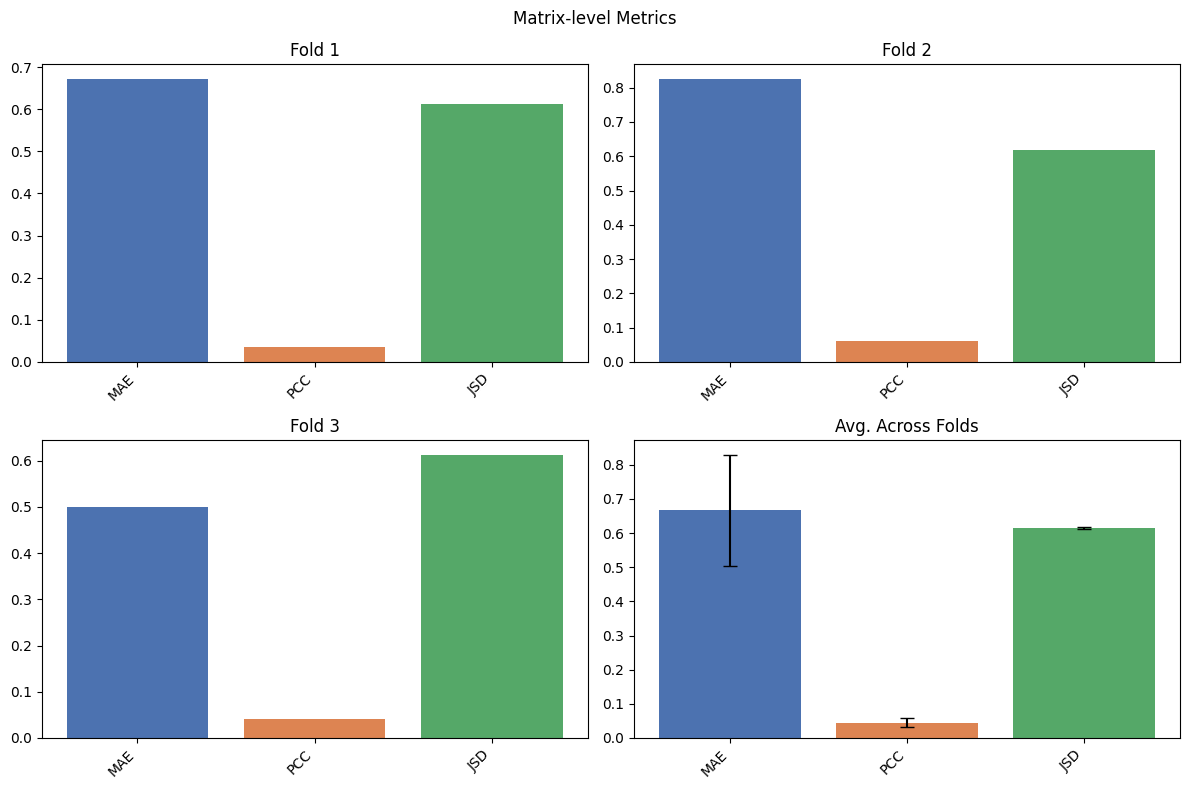

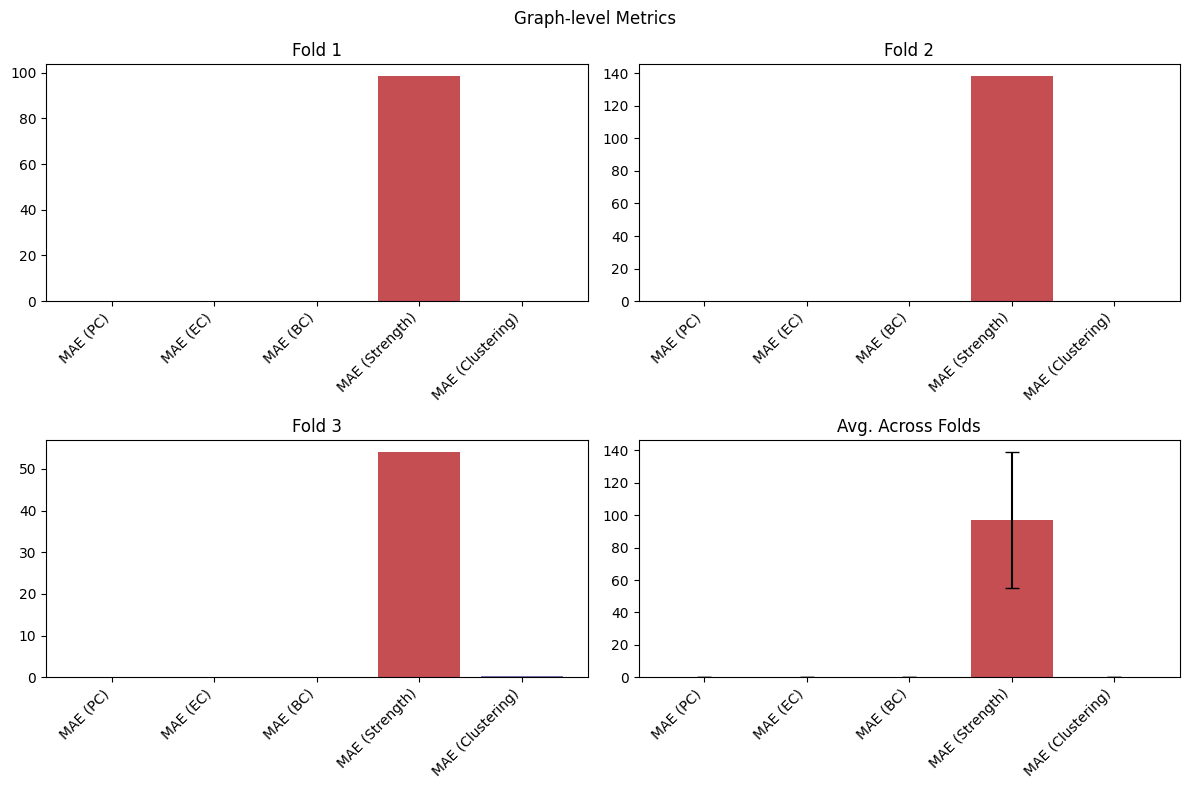

In [11]:
plot_folds(fold_metrics)

## Summary Statistics

In [12]:
import pandas as pd

# Aggregate metrics across folds
print("\n" + "="*60)
print("VGAE Baseline - Summary Statistics (3-Fold CV)")
print("="*60)

summary_data = {}
metric_names = fold_metrics[0].keys()

for metric_name in metric_names:
    values = [metrics[metric_name] for metrics in fold_metrics]
    mean_val = np.mean(values)
    std_val = np.std(values)
    summary_data[metric_name] = {'Mean': mean_val, 'Std': std_val}
    print(f'{metric_name:20s}: {mean_val:.6f} ± {std_val:.6f}')

print("\nPer-fold metrics:")
summary_df = pd.DataFrame(summary_data).T
for fold_id, metrics in enumerate(fold_metrics, start=1):
    for metric_name in metric_names:
        if fold_id == 1:
            summary_df[f'Fold {fold_id}'] = [metrics.get(m, np.nan) for m in metric_names]
        else:
            summary_df[f'Fold {fold_id}'] = [metrics.get(m, np.nan) for m in metric_names]

print(summary_df)


VGAE Baseline - Summary Statistics (3-Fold CV)
MAE                 : 0.666284 ± 0.133698
PCC                 : 0.045140 ± 0.010783
JSD                 : 0.615485 ± 0.002775
MAE (PC)            : 0.001110 ± 0.000010
MAE (EC)            : 0.023009 ± 0.000398
MAE (BC)            : 0.022016 ± 0.000351
MAE (Strength)      : 97.107009 ± 34.439346
MAE (Clustering)    : 0.236473 ± 0.003465

Per-fold metrics:
                       Mean        Std     Fold 1      Fold 2     Fold 3
MAE                0.666284   0.133698   0.672965    0.826587   0.499300
PCC                0.045140   0.010783   0.035105    0.060101   0.040213
JSD                0.615485   0.002775   0.613599    0.619408   0.613448
MAE (PC)           0.001110   0.000010   0.001097    0.001118   0.001117
MAE (EC)           0.023009   0.000398   0.022579    0.023538   0.022911
MAE (BC)           0.022016   0.000351   0.022114    0.022388   0.021546
MAE (Strength)    97.107009  34.439346  98.670574  138.482898  54.167555
MAE (Cluste

## Generate Kaggle Submission (Ensemble of 3 Folds)

In [13]:
test_preds = []
for i, model in enumerate(fold_models):
    model.eval()
    loader = DataLoader(
        TensorDataset(to_tensor(X_lr_test, DEVICE)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    preds = []
    with torch.no_grad():
        for (x_vec,) in loader:
            A = vec_to_adj(x_vec, N_LR)
            X = lr_node_features(A)
            preds.append(model(A, X).cpu().numpy())
    test_preds.append(np.concatenate(preds))
    print(f'Fold {i+1} test predictions: {test_preds[-1].shape}')

ensemble = np.clip(np.mean(test_preds, axis=0), a_min=0.0, a_max=None)
print(f'\nEnsemble shape: {ensemble.shape}')
print(f'Range: [{ensemble.min():.6f}, {ensemble.max():.6f}]')

Fold 1 test predictions: (112, 35778)
Fold 2 test predictions: (112, 35778)
Fold 3 test predictions: (112, 35778)

Ensemble shape: (112, 35778)
Range: [0.000000, 29.024872]


## Save Submission CSV

In [15]:
# Generate submission CSV
submission = pd.DataFrame({
    'index': np.arange(len(ensemble)),
    'hr_avg': list(ensemble)
})

submission_path = repo_root / 'vgae_baseline_submission.csv'
submission.to_csv(submission_path, index=False)
print(f'Submission saved to {submission_path}')
print(f'Shape: {submission.shape}')
print(submission.head())

Submission saved to /vol/bitbucket/vl522/neurores-gnn/vgae_baseline_submission.csv
Shape: (112, 2)
   index                                             hr_avg
0      0  [0.4571662, 1.1661716, 0.40546057, 0.080310754...
1      1  [0.49463692, 1.0552655, 0.32752758, 0.92869526...
2      2  [0.9688849, 0.57650095, 0.07899339, 0.0, 0.190...
3      3  [0.13081777, 0.026162611, 0.9197702, 0.0237441...
4      4  [0.6694043, 1.7187947, 0.26276794, 0.025355285...
